<a href="https://colab.research.google.com/github/pengin-cmd/my-colab-notebooks/blob/main/%E3%82%B3%E3%83%B3%E3%83%9A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost catboost optuna lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 25.5 MB/s eta 0:00:00


In [ ]:
!pip install optuna

In [ ]:
pip install lifetimes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 3.5 MB/s eta 0:00:00


全 19 個のファイルを自動認識し、散布図を 'acu_loss_distribution_auto.png' として保存しました。


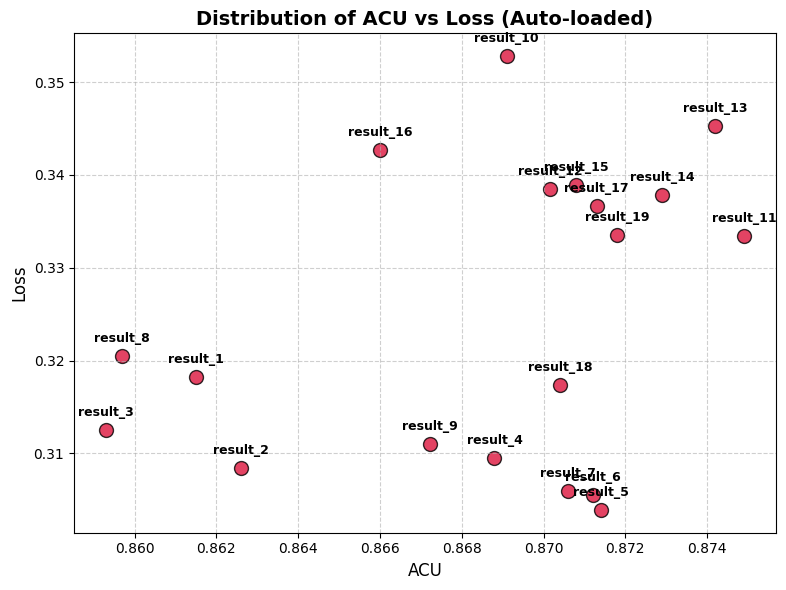

In [ ]:
import glob
import os
import re
import matplotlib.pyplot as plt
import pandas as pd

# 1. 実行中のディレクトリ（または特定のフォルダ）内から 'result_' で始まるCSVファイルを自動検索
# ※スクリプトと同じフォルダにあるファイルを対象にする場合はこれで動作します
csv_files = glob.glob("result_*.csv")

data = []
# ファイル名から「番号」「ACU」「Loss」を抽出する正規表現パターン
pattern = r"result_(\d+)\(ACU([\d\.]+),Loss([\d\.]+)\)\.csv"

# 2. 自動取得したファイル群から情報を抽出
for f in csv_files:
    # パス（フォルダ名など）が含まれている場合を考慮し、純粋なファイル名のみを抽出
    basename = os.path.basename(f)

    match = re.match(pattern, basename)
    if match:
        num = int(match.group(1))
        acu = float(match.group(2))
        loss = float(match.group(3))
        data.append({"result_num": num, "ACU": acu, "Loss": loss})

# データが1つも見つからなかった場合の処理
if not data:
    print(
        "条件（result_数字(ACU...,Loss...).csv）に一致するファイルが見つかりませんでした。"
    )
else:
    # 3. データを結果の番号順（1, 2, 3...）に並び替えてDataFrameに変換
    df_metrics = pd.DataFrame(data).sort_values(by="result_num").reset_index(drop=True)

    # 4. 散布図のプロット
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.scatter(
        df_metrics["ACU"],
        df_metrics["Loss"],
        color="crimson",
        s=100,
        edgecolors="black",
        alpha=0.8,
        label="Results",
    )

    # 各プロット点に対応する結果番号を注釈として自動追加
    for i, txt in enumerate(df_metrics["result_num"]):
        ax.annotate(
            f"result_{txt}",
            (df_metrics["ACU"].iloc[i], df_metrics["Loss"].iloc[i]),
            textcoords="offset points",
            xytext=(0, 10),
            ha="center",
            fontsize=9,
            fontweight="bold",
        )

    # 軸ラベルとタイトルの設定
    ax.set_xlabel("ACU", fontsize=12)
    ax.set_ylabel("Loss", fontsize=12)
    ax.set_title(
        "Distribution of ACU vs Loss (Auto-loaded)", fontsize=14, fontweight="bold"
    )
    ax.grid(True, linestyle="--", alpha=0.6)

    # レイアウトの自動調整
    plt.tight_layout()

    # 5. 画像の保存
    output_image = "acu_loss_distribution_auto.png"
    plt.savefig(output_image, dpi=300)
    print(
        f"全 {len(df_metrics)} 個のファイルを自動認識し、散布図を '{output_image}' として保存しました。"
    )

In [ ]:
import pandas as pd
import numpy as np
import warnings
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.tree import DecisionTreeClassifier, export_text
from lightgbm import LGBMClassifier, early_stopping
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ==========================================
# 0. 絶対にリークしない事前処理（行単位の処理）
# ==========================================
def preprocess_safe_row_wise(df):
    """
    他行のデータに依存しない処理（日付計算や特徴量追加など）は分割前に行ってOK。
    ※人間の感覚による手動の列削除（drop）は行わず、モデルに取捨選択を委ねる。
    """
    df = df.copy()
    base_date = pd.to_datetime('2015-01-01')

    if 'registration_date' in df.columns:
        df['days_since_registration'] = (base_date - pd.to_datetime(df['registration_date'])).dt.days
        df = df.drop('registration_date', axis=1)

    # --- 💡 特徴量エンジニアリング（ドメイン知識の反映） ---
    # 1. 一見さん排除フィルター
    if all(c in df.columns for c in ['spend_wines', 'spend_meat', 'days_since_last_purchase']):
        df['recent_loyalty'] = (df['spend_wines'] + df['spend_meat']) / (df['days_since_last_purchase'] + 1)

    # 2. カタログと肉の相性
    if all(c in df.columns for c in ['spend_meat', 'catalog_purchases']):
        df['meat_catalog_ratio'] = df['spend_meat'] / (df['catalog_purchases'] + 1)

    # 3. 割引ハンター度
    if all(c in df.columns for c in ['deals_purchases', 'store_purchases', 'web_purchases', 'catalog_purchases']):
        total_purchases = df['store_purchases'] + df['web_purchases'] + df['catalog_purchases']
        df['discount_hunter'] = df['deals_purchases'] / (total_purchases + 1)

        # 究極のキャンペーン相性スコア (VIP × 割引好き)
        if 'recent_loyalty' in df.columns:
            df['campaign_affinity'] = df['recent_loyalty'] * df['discount_hunter']
    # ==========================================
    # 💡 経営学・マーケティング理論に基づく新特徴量
    # ==========================================

    # --- 1. AOV (客単価) ---
    if all(c in df.columns for c in ['store_purchases', 'web_purchases', 'catalog_purchases',
                                     'spend_wines', 'spend_fruits', 'spend_meat', 'spend_fish', 'spend_sweets', 'spend_gold']):
        total_purchases = df['store_purchases'] + df['web_purchases'] + df['catalog_purchases']
        total_spend = df['spend_wines'] + df['spend_fruits'] + df['spend_meat'] + df['spend_fish'] + df['spend_sweets'] + df['spend_gold']

        # 1回あたりの平均購入金額（客単価）
        df['average_order_value'] = total_spend / (total_purchases + 1)

        # --- 2. HHI (購買カテゴリの集中度/寡占度) ---
        # 各カテゴリの支出割合（Share of Wallet）を計算
        share_wines = df['spend_wines'] / (total_spend + 1)
        share_fruits = df['spend_fruits'] / (total_spend + 1)
        share_meat = df['spend_meat'] / (total_spend + 1)
        share_fish = df['spend_fish'] / (total_spend + 1)
        share_sweets = df['spend_sweets'] / (total_spend + 1)
        share_gold = df['spend_gold'] / (total_spend + 1)

        # HHIの計算（割合の2乗和。1に近いほど特定カテゴリに極端に偏っている）
        df['hhi_category_concentration'] = (share_wines**2 + share_fruits**2 + share_meat**2 +
                                            share_fish**2 + share_sweets**2 + share_gold**2)

    # --- 3. オムニチャネル依存度 (Channel Preference) ---
    if all(c in df.columns for c in ['store_purchases', 'web_purchases', 'catalog_purchases']):
        total_purchases_for_ratio = df['store_purchases'] + df['web_purchases'] + df['catalog_purchases']
        # 全購入に占める実店舗の割合
        df['store_reliance_ratio'] = df['store_purchases'] / (total_purchases_for_ratio + 1)
        # 全購入に占めるWebの割合
        df['web_reliance_ratio'] = df['web_purchases'] / (total_purchases_for_ratio + 1)

    # --- 4. 休眠リスク指数 (Churn Risk Index) ---
    if all(c in df.columns for c in ['days_since_last_purchase', 'days_since_registration']):
        # 登録期間のうち、どれくらいの割合を「購入せずに放置」しているか
        df['churn_risk_index'] = df['days_since_last_purchase'] / (df['days_since_registration'] + 1)

    return df

# ==========================================
# 1. Optuna (パラメータチューニング)
# ==========================================
def tune_lightgbm_with_optuna(X_raw, y, n_trials=15):
    print("\n--- [1. Optuna パラメータ最適化] ---")

    def objective(trial):
        params = {
            'random_state': 42,
            'n_estimators': 500,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'num_leaves': trial.suggest_int('num_leaves', 15, 63),
            'class_weight': 'balanced',
            'verbose': -1
        }

        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        oof = np.zeros(len(X_raw))

        for tr_idx, va_idx in skf.split(X_raw, y):
            X_tr, y_tr = X_raw.iloc[tr_idx].copy(), y.iloc[tr_idx]
            X_va, y_va = X_raw.iloc[va_idx].copy(), y.iloc[va_idx]

            med = X_tr['annual_income'].median()
            X_tr['annual_income'] = X_tr['annual_income'].fillna(med)
            X_va['annual_income'] = X_va['annual_income'].fillna(med)

            cols = ['education_level', 'marital_status']
            enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
            X_tr[cols] = enc.fit_transform(X_tr[cols])
            X_va[cols] = enc.transform(X_va[cols])

            model = LGBMClassifier(**params)
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_va, y_va)],
                callbacks=[early_stopping(stopping_rounds=30, verbose=False)]
            )

            oof[va_idx] = model.predict_proba(X_va)[:, 1]

        return roc_auc_score(y, oof)

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)

    best_params = study.best_params
    best_params.update({'random_state': 42, 'n_estimators': 1000, 'class_weight': 'balanced', 'verbose': -1})
    return best_params

# ==========================================
# 2. 学習フェーズ (Train & Validate)
# ==========================================
def train_models(X_raw, y, lgb_best_params, seeds=[42, 2023, 777], n_splits=5):
    print(f"\n--- [2. 学習フェーズ開始 (Testデータは一切使用しません)] ---")

    artifacts = []
    oof_preds_ensemble = np.zeros(len(X_raw))
    ratio = float(np.sum(y == 0)) / np.sum(y == 1)

    for seed in seeds:
        print(f">> Running Seed: {seed}...")
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        oof_seed = np.zeros(len(X_raw))

        for fold, (train_idx, val_idx) in enumerate(skf.split(X_raw, y)):
            X_tr, y_tr = X_raw.iloc[train_idx].copy(), y.iloc[train_idx]
            X_va, y_va = X_raw.iloc[val_idx].copy(), y.iloc[val_idx]

            income_median = X_tr['annual_income'].median()
            X_tr['annual_income'] = X_tr['annual_income'].fillna(income_median)
            X_va['annual_income'] = X_va['annual_income'].fillna(income_median)

            categorical_cols = ['education_level', 'marital_status']
            encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
            X_tr[categorical_cols] = encoder.fit_transform(X_tr[categorical_cols])
            X_va[categorical_cols] = encoder.transform(X_va[categorical_cols])

            lgb_params = lgb_best_params.copy()
            lgb_params['random_state'] = seed

            models = {
                'LightGBM': LGBMClassifier(**lgb_params),
                'XGBoost': XGBClassifier(random_state=seed, n_estimators=1000, learning_rate=0.05, max_depth=5, scale_pos_weight=ratio, early_stopping_rounds=50, eval_metric='logloss'),
                'RandomForest': RandomForestClassifier(random_state=seed, n_estimators=100, max_depth=10, class_weight='balanced')
            }

            fold_val_preds = np.zeros(len(X_va))
            for name, model in models.items():
                if name == 'LightGBM':
                    # 【修正】本番学習時もEarly Stoppingを適用して過学習を防ぐ
                    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[early_stopping(stopping_rounds=30, verbose=False)])
                elif name == 'XGBoost':
                    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
                else:
                    model.fit(X_tr, y_tr)

                fold_val_preds += model.predict_proba(X_va)[:, 1] / len(models)

            oof_seed[val_idx] = fold_val_preds

            artifacts.append({
                'seed': seed,
                'fold': fold,
                'preprocessors': {
                    'income_median': income_median,
                    'encoder': encoder,
                    'cat_cols': categorical_cols
                },
                'models': models,
                'feature_names': list(X_tr.columns)
            })

        oof_preds_ensemble += oof_seed / len(seeds)

    # --- 修正箇所：最終的なローカルCVスコア（AUC）と損失（Log Loss）の計算と出力 ---
    final_cv_score = roc_auc_score(y, oof_preds_ensemble)
    final_cv_loss = log_loss(y, oof_preds_ensemble)
    print(f"✅ 学習完了: 最終 OOF AUC (CVスコア): {final_cv_score:.4f} / 最終 Log Loss (損失): {final_cv_loss:.4f}")

    return artifacts, oof_preds_ensemble

# ==========================================
# 3. 予測フェーズ (Predict)
# ==========================================
def predict_models(X_test_raw, artifacts):
    print("\n--- [3. 予測フェーズ開始] ---")
    final_test_preds = np.zeros(len(X_test_raw))
    total_models = 0

    for artifact in artifacts:
        X_te = X_test_raw.copy()
        preps = artifact['preprocessors']
        models = artifact['models']

        X_te['annual_income'] = X_te['annual_income'].fillna(preps['income_median'])
        X_te[preps['cat_cols']] = preps['encoder'].transform(X_te[preps['cat_cols']])

        for name, model in models.items():
            final_test_preds += model.predict_proba(X_te)[:, 1]
            total_models += 1

    final_test_preds /= total_models
    print(f"✅ 予測完了: 計 {total_models} 個のモデルによるアンサンブル予測を実行しました。")
    return final_test_preds

# ==========================================
# 4. エラー分析 ＆ 損失原因度(Error Importance)のグラフ化
# ==========================================
def analyze_error_patterns(X_raw, y, oof_preds):
    print("\n--- [4. エラー分析 (損失原因の特定)] ---")

    error_df = X_raw.copy()
    error_df['target'] = y
    error_df['pred_prob'] = oof_preds
    error_df['pred_class'] = (oof_preds >= 0.5).astype(int)

    error_df['is_error'] = (error_df['target'] != error_df['pred_class']).astype(int)
    print(f"▼ 全体のエラー件数 (is_error = 1): {error_df['is_error'].sum()} 件 / {len(error_df)} 件")

    X_error = X_raw.copy()
    X_error['annual_income'] = X_error['annual_income'].fillna(X_error['annual_income'].median())

    cols = ['education_level', 'marital_status']
    X_error[cols] = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1).fit_transform(X_error[cols])

    error_model = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, class_weight='balanced')
    error_model.fit(X_error, error_df['is_error'])

    error_importance = pd.DataFrame({
        'Feature': X_error.columns,
        'Error_Importance': error_model.feature_importances_ * 100
    }).sort_values(by='Error_Importance', ascending=False).reset_index(drop=True)

    print("\n▼ 損失原因度ランキング トップ5 (モデルを騙している戦犯):")
    print(error_importance.head(5))

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Error_Importance', y='Feature', data=error_importance, palette='magma')
    plt.title('Error Importances (What causes the model to fail?)', fontsize=14)
    plt.xlabel('Contribution to Error (%)', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.tight_layout()
    plt.show()

    dt = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
    dt.fit(X_error, error_df['is_error'])
    print("\n▼ AIがエラーを起こす条件ルール (is_error=1 になりやすい分岐):")
    print(export_text(dt, feature_names=list(X_error.columns)))

    return error_importance

# ==========================================
# 5. 特徴量重要度 (Feature Importance)のグラフ化
# ==========================================
def plot_feature_importances(artifacts):
    print("\n--- [5. 特徴量重要度の算出] ---")
    f_names = artifacts[0]['feature_names']
    importance_df = pd.DataFrame({'Feature': f_names})

    total_imps = np.zeros(len(f_names))
    total_models = 0
    scaler = MinMaxScaler() # 【修正】重要度を0〜1に正規化するためのスケーラー

    for art in artifacts:
        for name, model in art['models'].items():
            # 各モデルの重要度を取得し、2次元配列に変換して正規化
            raw_imp = model.feature_importances_
            scaled_imp = scaler.fit_transform(raw_imp.reshape(-1, 1)).flatten()
            total_imps += scaled_imp
            total_models += 1

    # 正規化された重要度の平均を計算し、全体を100%としてスケールし直す
    importance_df['Total_Average'] = (total_imps / total_models)
    importance_df['Total_Average'] = (importance_df['Total_Average'] / importance_df['Total_Average'].sum()) * 100
    importance_df = importance_df.sort_values(by='Total_Average', ascending=False).reset_index(drop=True)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Total_Average', y='Feature', data=importance_df, palette='viridis')
    plt.title('Feature Importances (Normalized Ensemble Average)', fontsize=14)
    plt.xlabel('Relative Importance (%)', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.tight_layout()
    plt.show()

    return importance_df

# ==========================================
# メイン実行ブロック
# ==========================================
if __name__ == "__main__":
    # 実環境に合わせてファイルパスを調整してください
    train_data = pd.read_csv('train.csv')
    test_data = pd.read_csv('test.csv')

    # ① データの準備
    train_df = preprocess_safe_row_wise(train_data)
    test_df = preprocess_safe_row_wise(test_data)

    X_raw = train_df.drop(['customer_id', 'target'], axis=1)
    y = train_df['target']
    X_test_raw = test_df.drop(['customer_id'], axis=1, errors='ignore')

    # ② パラメータ最適化 (実務ではn_trialsを増やしてください)
    best_lgb_params = tune_lightgbm_with_optuna(X_raw, y, n_trials=10)

    # ③ 【学習フェーズ】 モデルの訓練とアーティファクトの取得
    artifacts, oof_predictions = train_models(X_raw, y, best_lgb_params)

    # ④ 【予測フェーズ】 未知のデータをアーティファクトで推論
    final_predictions = predict_models(X_test_raw, artifacts)

    # ⑤ 分析・可視化
    analyze_error_patterns(X_raw, y, oof_predictions)
    plot_feature_importances(artifacts)

    # ⑥ 出力
    submission = pd.DataFrame({'customer_id': test_data['customer_id'], 'target': final_predictions})
    submission.to_csv('final_submission_robust.csv', index=False)
    print("\n✅ 全工程完了: 'final_submission_robust.csv' を出力しました！")